In [1]:
import sys
import os
sys.path.append(os.path.abspath('../../..'))
from src.models.n_gram_network import Tokenizer, NGramNetwork
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
%matplotlib inline

With training set:
- with: 64 batch size
- sharp decline from 1_000 till 10_000, then it suddenly stops and stays at 2.08 on test set
- that means 10_000 is the ideal iteration number for this test set
- 64 * 10_000 = 640_000 inputs looked at; 47524 items in test set -> 13.5 rehearsing ratio is the ideal for this set

With dev set:
- with: 64 batch size
- sharp decline from 1_000 till 10_000, 4.2 -> 3.7 loss, then it stablilizes.

This means that set size does not change the iteration number required for stabilization,
but it DOES change the loss it converges to.

This means that the thing limiting my loss decrease is the minimum clamp of the 
learning rate.

In [2]:
# Hyperparameters

context_size = 3
embedding_vector_size = 8
w1_out = 256
batch_size = 64
#iterations = 10_000

q = 10
t = 10_000


def learning_rate_function(i:float) -> float:
    return q ** (-i / t)

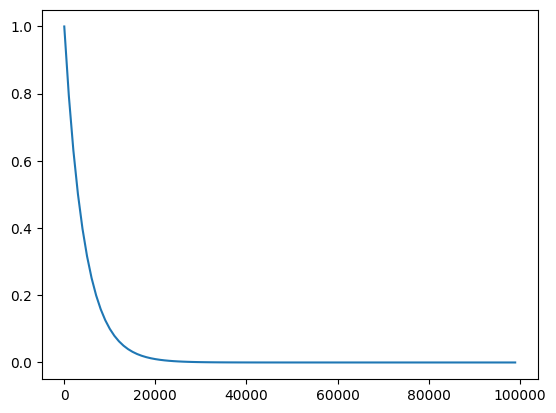

In [3]:
x = np.arange(1, 100_000, 1_000)
plt.plot(x, q ** (-x / t))

In [4]:
# Initializations for network

data_path = '../../../src/data/normalized/en_cities.txt'
tokenizer = Tokenizer(data_path)

In [5]:
def test_iterations(iterations: int) -> float:
    # Init and train network
    network = NGramNetwork(context_size, tokenizer, data_path, embedding_vector_size, w1_out)
    network.train(batch_size, iterations, learning_rate_function, print_out=False, use_dev_set=True)
    
    # Return test set loss
    return network.evaluate_test_set()
    
    

In [6]:
# Test w1_outs from 8 to 512:
iters = []
losses = []
times = []

for iteration in range(1_000, 64_000, 1_000):
    start_time = time.perf_counter()
    
    loss = test_iterations(iteration)

    elapsed_time = time.perf_counter() - start_time
    
    iters.append(iteration)
    losses.append(loss)
    times.append(elapsed_time)
    
    print(iteration, '-->', loss)

1000 --> 3.895914077758789
2000 --> 3.665987014770508
3000 --> 3.6841542720794678
4000 --> 3.6688928604125977
5000 --> 3.645249843597412
6000 --> 3.670717477798462
7000 --> 3.7358996868133545
8000 --> 3.6861088275909424
9000 --> 3.689673662185669
10000 --> 3.7268078327178955
11000 --> 3.713463544845581
12000 --> 3.7066965103149414
13000 --> 3.740269184112549
14000 --> 3.765242338180542
15000 --> 3.7799911499023438
16000 --> 3.7642810344696045
17000 --> 3.7476887702941895
18000 --> 3.791630744934082
19000 --> 3.787874460220337
20000 --> 3.7556607723236084
21000 --> 3.799421787261963
22000 --> 3.7677812576293945
23000 --> 3.8306691646575928
24000 --> 3.784292697906494
25000 --> 3.719970941543579
26000 --> 3.8239827156066895
27000 --> 3.7837300300598145
28000 --> 3.799708604812622
29000 --> 3.7980289459228516
30000 --> 3.7575998306274414
31000 --> 3.7703211307525635
32000 --> 3.8121466636657715
33000 --> 3.766260862350464
34000 --> 3.7489657402038574
35000 --> 3.7330355644226074
36000 -->

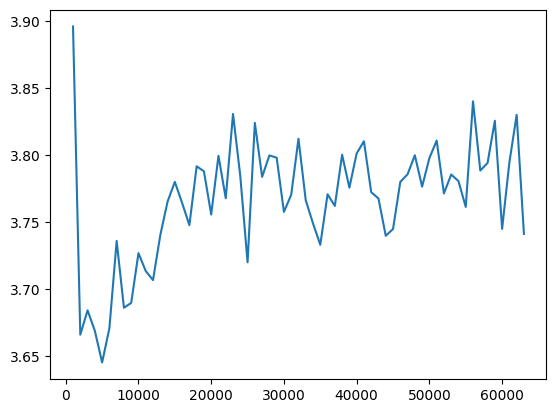

In [7]:
plt.plot(iters, losses)
plt.show()

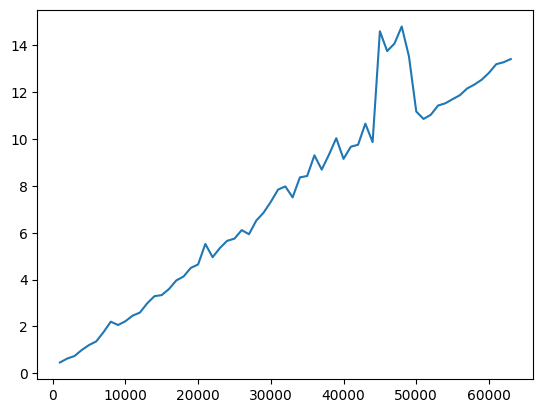

In [8]:
plt.plot(iters, times)
plt.show()

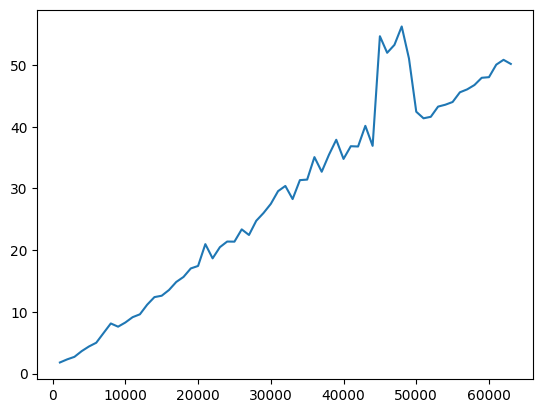

In [9]:
x = np.array(losses) * np.array(times)
plt.plot(iters, x)
plt.show()